#**BLINKIT ANALYSIS**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv('/content/drive/MyDrive/Essential pdf for Interviews /blinkit_data.csv')
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [27]:
df.drop('Item Weight',axis=1,inplace=True)

In [28]:
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Sales,0


In [29]:
df.shape

(8523, 11)

In [30]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [31]:
df['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'},inplace=True)


/tmp/ipython-input-3187863313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'},inplace=True)


In [32]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,55.1614,5.0


In [33]:
total_sales = df['Sales'].sum()
avg_sales = df['Sales'].mean()
no_of_items = df['Item Identifier'].count()
avg_rating = df['Rating'].mean()

print(f'Total Sales: ${total_sales:,.0f}')
print(f'Average Sales: ${avg_sales:,.0f}')
print(f'Number of Items: {no_of_items:,.0f}')
print(f'Average Rating: {avg_rating:,.0f}')


Total Sales: $1,201,681
Average Sales: $141
Number of Items: 8,523
Average Rating: 4


**CHART REQUIREMENTS**

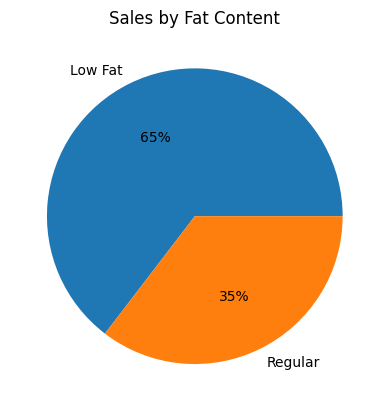

In [36]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%1.0f%%')
plt.title('Sales by Fat Content')
plt.show()

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9204
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4596
Canned                    90706.7270
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1650
Breads                    35379.1198
Hard Drinks               29334.6766
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64


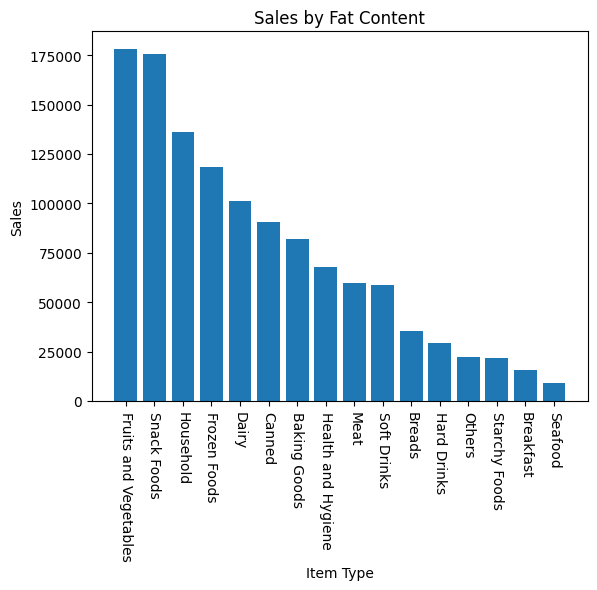

In [45]:
sales_by_item = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
print(sales_by_item)
bars=plt.bar(sales_by_item.index, sales_by_item.values)
plt.xticks(rotation=-90)
plt.ylabel('Sales')
plt.xlabel('Item Type')
plt.title('Sales by Fat Content')
plt.show()


Item Fat Content          Low Fat      Regular
Outlet Location Type                          
Tier 1                215047.9126  121349.8994
Tier 2                254464.7734  138685.8682
Tier 3                306806.9924  165326.0348


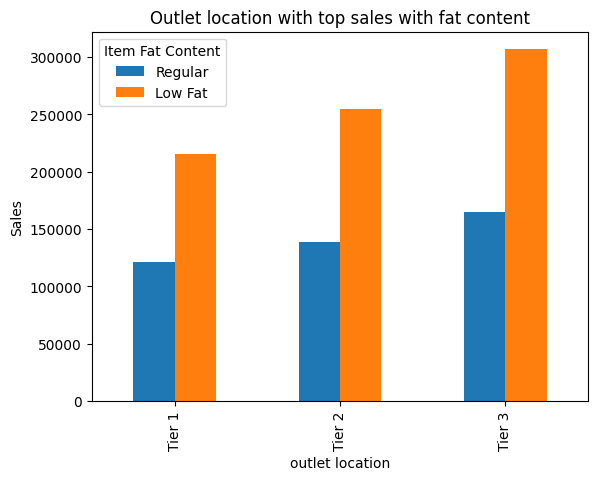

In [46]:
grouped = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
print(grouped)
grouped = grouped[['Regular','Low Fat']]
ax= grouped.plot(kind='bar')
plt.xlabel('outlet location')
plt.ylabel('Sales')
plt.legend(title='Item Fat Content')
plt.title('Outlet location with top sales with fat content')
plt.show()

Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Sales, dtype: float64


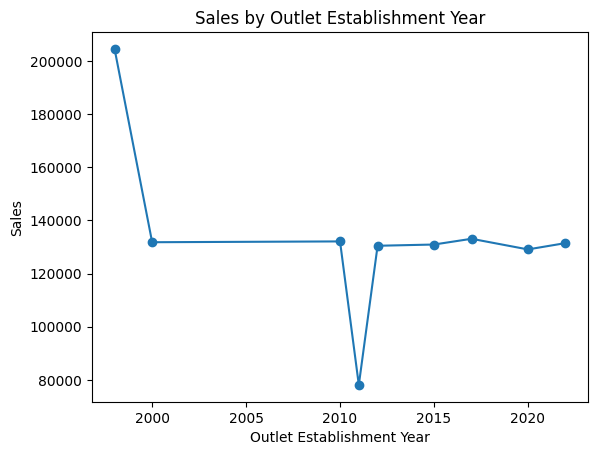

In [49]:
sales_by_outletyear = df.groupby(['Outlet Establishment Year'])['Sales'].sum()
print(sales_by_outletyear)
plt.plot(sales_by_outletyear.index, sales_by_outletyear.values,marker='o')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Sales')
plt.title('Sales by Outlet Establishment Year')
plt.show()

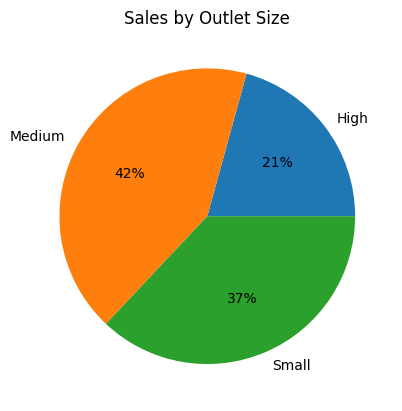

In [50]:
sales_by_outletsize = df.groupby('Outlet Size')['Sales'].sum()
plt.pie(sales_by_outletsize, labels=sales_by_outletsize.index, autopct='%1.0f%%')
plt.title('Sales by Outlet Size')
plt.show()

Outlet Location Type
Tier 1    336397.8120
Tier 2    393150.6416
Tier 3    472133.0272
Name: Sales, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

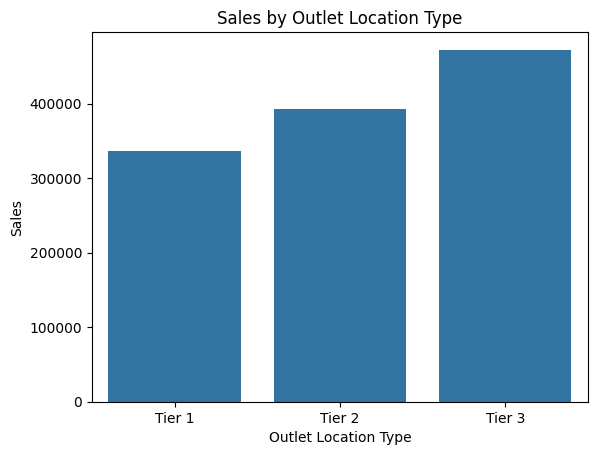

In [53]:
sales_by_outletlocate = df.groupby('Outlet Location Type')['Sales'].sum()
print(sales_by_outletlocate)
ax = sns.barplot(x=sales_by_outletlocate.index, y=sales_by_outletlocate.values)
plt.xlabel('Outlet Location Type')
plt.ylabel('Sales')
plt.title('Sales by Outlet Location Type')
plt.show